# Taller: Clustering con K-Means sobre datos sintéticos 2D

Por:
* Isabella Arrieta
* Natalia Carpintero
* Paula Núñez

## 1. Librerías necesarias

Se importan las librerías de manejo numérico (`numpy`), visualización (`matplotlib`),
manejo tabular (`pandas`) y las herramientas de *machine learning* de `scikit-learn`
que se usarán en todo el taller:

- `KMeans`: algoritmo de agrupamiento.
- `silhouette_score` / `silhouette_samples`: métrica interna de calidad del clustering.
- `LocalOutlierFactor`: detección no supervisada de outliers (se usa para removerlos,
  tal como pide el enunciado).
- `adjusted_rand_score` y `normalized_mutual_info_score`: métricas que comparan el
  clustering obtenido contra las etiquetas verdaderas (ground truth).

In [33]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.neighbors import LocalOutlierFactor

# Semilla global para que todo el cuaderno sea reproducible
SEED = 42
rng = np.random.default_rng(SEED)

## 2. Generación del conjunto de datos sintético

Se deben cumplir **todas** estas condiciones sobre los datos:

| Requisito | Cómo se cumple |
|---|---|
| 6 grupos | `n_clusters_real = 6` |
| Distribuciones gaussianas **isotrópicas** | Para cada grupo se generan puntos con `rng.normal(0, sigma, (n, 2))`: misma desviación estándar en ambos ejes ⇒ la matriz de covarianza es `sigma² · I` (diagonal e igual en ambas direcciones) |
| Diferentes densidades | Cada grupo tiene el **mismo número de puntos** (`n_por_cluster`) pero **diferente `sigma`**, por lo que unos quedan más compactos (más densos) que otros |
| Todo entre -10 y 10 | Los centros y las desviaciones se escogieron para que, con altísima probabilidad, ningún punto se salga del rango; adicionalmente se aplica un `clip` de seguridad y una aserción (`assert`) que verifica el rango al final |
| Dos grupos cercanos y parcialmente superpuestos | Los grupos 4 y 5 se ubican deliberadamente cerca, con una distancia entre centros comparable a la suma de sus desviaciones estándar |
| Outliers uniformes | Se agregan puntos adicionales con `rng.uniform(-10, 10)` en ambos ejes, etiquetados como `-1` (no pertenecen a ningún grupo real) |

Se guarda también el vector `y_true_all`, que funciona como **ground truth**: contiene el
número de grupo real (0 a 5) para cada punto generado, o `-1` si el punto es un outlier.
Este vector **no se usa para entrenar** K-Means (K-Means es no supervisado), solo se usa
después para evaluar qué tan buenos son los distintos criterios de selección de K.

In [44]:
# ------------------------------------------------------------------
# Parámetros de los 6 grupos "reales"
# ------------------------------------------------------------------
n_clusters_real = 6
n_por_cluster = 200  # MISMO número de puntos en cada grupo (requisito del enunciado)

# Centros de cada grupo. Se ubican en las esquinas del plano para tener grupos bien
# separados, salvo los grupos 4 y 5, que se colocan cerca a propósito para que se
# superpongan parcialmente como dice el enunciado.
centros = np.array([
    [-6.0,  6.0],   # grupo 0
    [ 6.0,  6.0],   # grupo 1
    [-6.0, -6.0],   # grupo 2
    [ 6.0, -6.0],   # grupo 3
    [-0.5,  0.0],   # grupo 4  -> cerca del grupo 5
    [ 2.0,  1.0],   # grupo 5  -> cerca del grupo 4 (superposición parcial)
])

# Diferentes densidades: mismo # de puntos y diferentes desviaciones estándar.
sigmas = np.array([0.5, 0.7, 0.6, 0.9, 1.3, 1.0])

# Validaciones
assert centros.shape[0] == n_clusters_real, "Debe haber un centro por cada grupo"
assert sigmas.shape[0] == n_clusters_real, "Debe haber una sigma por cada grupo"

# ------------------------------------------------------------------
# Generación de los puntos de cada grupo (distribución gaussiana isotrópica)
# ------------------------------------------------------------------
X_list, y_list = [], []
for i in range(n_clusters_real):
    # rng.normal con un solo "scale" para ambas columnas => misma varianza en X e Y
    # se usa porque el enunciado pidió distribución gaussiana isotrópica (varianza igual en todas las direcciones)
    puntos = rng.normal(loc=0.0, scale=sigmas[i], size=(n_por_cluster, 2)) + centros[i] # genera números aleatorios
    X_list.append(puntos)
    y_list.append(np.full(n_por_cluster, i))

X_grupos = np.vstack(X_list)
y_grupos = np.concatenate(y_list)

# Validación: mismo número de puntos por grupo
conteos = np.unique(y_grupos, return_counts=True)[1]
assert np.all(conteos == n_por_cluster), "Todos los grupos deben tener el mismo número de puntos"

# Validación: garantiza el rango [-10, 10] pedido por el enunciado.
n_fuera_de_rango = int((np.abs(X_grupos) > 10).any(axis=1).sum())
if n_fuera_de_rango > 0:
    print(f"Se recortaron {n_fuera_de_rango} puntos que se salían del rango [-10, 10]")
X_grupos = np.clip(X_grupos, -10, 10)
# Se baraja el orden para que la posición en el arreglo no delate a qué grupo pertenece
idx = rng.permutation(len(X_all))
X_all = X_all[idx]
y_true_all = y_true_all[idx]
# ------------------------------------------------------------------
# Outliers: distribución uniforme entre -10 y 10 en ambos ejes
# ------------------------------------------------------------------
n_outliers = 100  # ~8% del total de puntos "reales"
X_outliers = rng.uniform(low=-10, high=10, size=(n_outliers, 2))
y_outliers = np.full(n_outliers, -1)  # -1 = outlier, no pertenece a ningún grupo real

# ------------------------------------------------------------------
# Unión del dataset completo y validación final de rango
# ------------------------------------------------------------------
X_all = np.vstack([X_grupos, X_outliers])
y_true_all = np.concatenate([y_grupos, y_outliers])

assert X_all.min() >= -10 and X_all.max() <= 10, "Hay puntos fuera del rango [-10, 10]" # Validación


print(f"\nTotal de puntos generados: {len(X_all)}")
print(f"  - Puntos de los 6 grupos reales: {len(X_grupos)} ({n_por_cluster} por grupo)")
print(f"  - Outliers: {len(X_outliers)}")
print(f"Rango final de los datos: [{X_all.min():.2f}, {X_all.max():.2f}]")


Total de puntos generados: 1300
  - Puntos de los 6 grupos reales: 1200 (200 por grupo)
  - Outliers: 100
Rango final de los datos: [-9.99, 9.87]


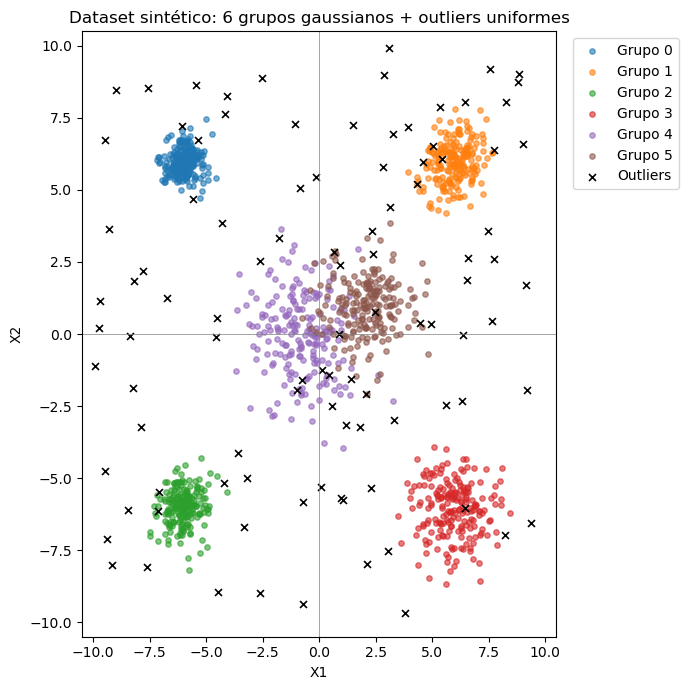

In [35]:
# Visualización del dataset generado: colores = grupo real, outliers en negro ('x')
fig, ax = plt.subplots(figsize=(7, 7))

for i in range(n_clusters_real):
    puntos_i = X_all[y_true_all == i]
    ax.scatter(puntos_i[:, 0], puntos_i[:, 1], s=15, alpha=0.6, label=f"Grupo {i}")

outliers_plot = X_all[y_true_all == -1]
ax.scatter(outliers_plot[:, 0], outliers_plot[:, 1], s=25, c="black", marker="x",
           label="Outliers", linewidths=1.2)

ax.set_xlim(-10.5, 10.5)
ax.set_ylim(-10.5, 10.5)
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_title("Dataset sintético: 6 grupos gaussianos + outliers uniformes")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 3. Remoción de outliers

Antes de aplicar K-Means se deben **remover los outliers**, tal como pide el enunciado.
En un escenario real no se conocen de antemano las etiquetas (`y_true_all`), así que la
detección se hace de forma **no supervisada** con `LocalOutlierFactor` (LOF), el mismo
método usado en el cuaderno de ejemplo.

LOF compara la densidad local de cada punto con la de sus vecinos: un punto en una zona
mucho menos densa que sus vecinos es marcado como outlier (`-1`); si tiene una densidad
comparable, se considera un punto normal o "inlier" (`1`).

Como LOF es no supervisado, no es perfecto: puede dejar pasar algunos outliers y, con
menor frecuencia, marcar por error algún punto de un grupo real como outlier. Esto se
reporta explícitamente abajo para ser transparentes con las limitaciones del método.

In [36]:
# contamination = proporción esperada de outliers en el dataset (se usa el valor real
# como referencia razonable, ~7-8%, algo que en la práctica se estima o se explora)
proporcion_outliers_esperada = n_outliers / len(X_all)
print(f"Proporción de outliers esperada: {proporcion_outliers_esperada:.3f}")

lof = LocalOutlierFactor(n_neighbors=35, contamination=proporcion_outliers_esperada)
es_inlier = lof.fit_predict(X_all)  # devuelve 1 (inlier) o -1 (outlier detectado)

X_clean = X_all[es_inlier == 1]
y_true_clean = y_true_all[es_inlier == 1]

# Reporte de la calidad de la detección (comparando contra el ground truth, solo
# para efectos informativos/de validación del preprocesamiento):
outliers_reales_detectados = np.sum((y_true_all == -1) & (es_inlier == -1))
outliers_reales_no_detectados = np.sum((y_true_all == -1) & (es_inlier == 1))
puntos_reales_removidos_por_error = np.sum((y_true_all != -1) & (es_inlier == -1))

print(f"\nPuntos antes de remover outliers: {len(X_all)}")
print(f"Puntos después de remover outliers: {len(X_clean)}")
print(f"  - Outliers reales correctamente detectados: {outliers_reales_detectados} / {n_outliers}")
print(f"  - Outliers reales que NO se detectaron (sobreviven en X_clean): {outliers_reales_no_detectados}")
print(f"  - Puntos de grupos reales removidos por error: {puntos_reales_removidos_por_error}")

Proporción de outliers esperada: 0.077

Puntos antes de remover outliers: 1300
Puntos después de remover outliers: 1200
  - Outliers reales correctamente detectados: 72 / 100
  - Outliers reales que NO se detectaron (sobreviven en X_clean): 28
  - Puntos de grupos reales removidos por error: 28


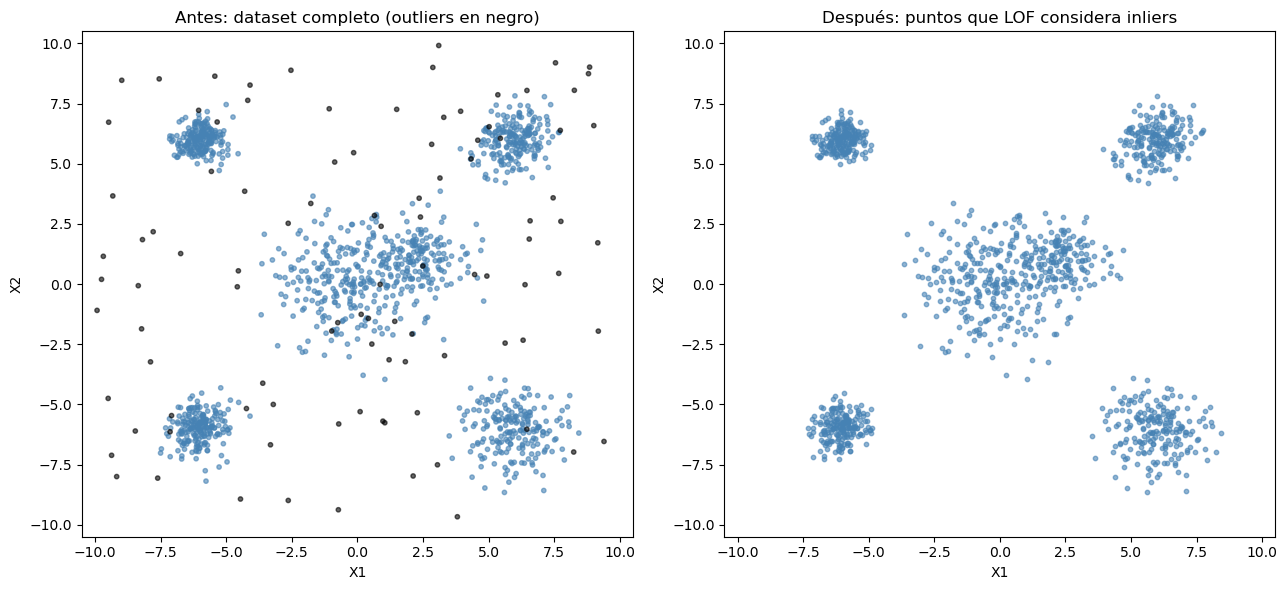

In [37]:
# Visualización antes / después de remover outliers
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].scatter(X_all[:, 0], X_all[:, 1], s=10, c=np.where(y_true_all == -1, "black", "steelblue"),
                alpha=0.6)
axes[0].set_title("Antes: dataset completo (outliers en negro)")

axes[1].scatter(X_clean[:, 0], X_clean[:, 1], s=10, c="steelblue", alpha=0.6)
axes[1].set_title("Después: puntos que LOF considera inliers")

for ax in axes:
    ax.set_xlim(-10.5, 10.5)
    ax.set_ylim(-10.5, 10.5)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

plt.tight_layout()
plt.show()

**Nota sobre la evaluación con ground truth:** los pocos outliers reales que LOF no
detecta quedan mezclados dentro de `X_clean`. K-Means sí se entrena con **todos** los
puntos de `X_clean` (así sería en un caso real, donde no se sabe cuáles son cuáles). Sin
embargo, para el método de selección de K basado en *ground truth* (sección 6), solo
tiene sentido comparar contra la etiqueta verdadera en los puntos que **sí** provienen de
alguno de los 6 grupos reales, así que se arma un subconjunto adicional (`X_eval`,
`y_eval_true`) excluyendo los outliers que sobrevivieron.

In [38]:
mask_con_etiqueta = y_true_clean != -1
X_eval = X_clean[mask_con_etiqueta]
y_eval_true = y_true_clean[mask_con_etiqueta]

print(f"Puntos usados para ENTRENAR K-Means (X_clean): {len(X_clean)}")
print(f"Puntos usados para EVALUAR contra ground truth (X_eval): {len(X_eval)}")

Puntos usados para ENTRENAR K-Means (X_clean): 1200
Puntos usados para EVALUAR contra ground truth (X_eval): 1172


## 4. Exploración de K entre 2 y 12

Se entrena un modelo de K-Means distinto para cada valor de `K` en el rango `[2, 12]`
sobre `X_clean` (ya sin outliers), y para cada uno se calculan las tres métricas que se
usarán en las siguientes secciones:

- **Inercia** (suma de distancias al cuadrado de cada punto a su centroide): insumo del
  **método del codo**.
- **Coeficiente de Silhouette promedio**: insumo del **método de Silhouette**.
- **Adjusted Rand Index (ARI)** y **Normalized Mutual Information (NMI)** frente a
  `y_eval_true`: insumo del **método basado en ground truth**.

Todo se guarda en una tabla (`pandas.DataFrame`) para facilitar su análisis y graficación.

In [39]:
K_range = range(2, 13)  # de 2 a 12 grupos, ambos incluidos

resultados = []
modelos_por_k = {}

for k in K_range:
    kmeans_k = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_clean = kmeans_k.fit_predict(X_clean)
    modelos_por_k[k] = kmeans_k

    inercia = kmeans_k.inertia_
    silhouette_avg = silhouette_score(X_clean, labels_clean)

    # Para comparar contra el ground truth solo se usan los puntos que sí
    # tienen una etiqueta real (mismo orden/índices que X_eval / y_eval_true).
    labels_eval = labels_clean[mask_con_etiqueta]
    ari = adjusted_rand_score(y_eval_true, labels_eval)
    nmi = normalized_mutual_info_score(y_eval_true, labels_eval)

    resultados.append({"K": k, "inercia": inercia, "silhouette": silhouette_avg,
                        "ARI": ari, "NMI": nmi})

df_resultados = pd.DataFrame(resultados).set_index("K")
df_resultados.round(4)

,inercia,silhouette,ARI,NMI
K,,,,
2,35618.5808,0.3986,0.2683,0.4577
3,23029.0832,0.5216,0.3223,0.6071
4,10625.0555,0.6506,0.5606,0.7854
5,2757.5458,0.7606,0.8209,0.9278
6,1745.0820,0.7048,0.9376,0.9461
7,1454.7152,0.6898,0.8902,0.9089
8,1309.1716,0.6695,0.8627,0.8917
9,1187.9074,0.5920,0.8001,0.8668
10,1091.2051,0.5853,0.7858,0.8557


## 5. Método del codo (Elbow Method)

La inercia siempre disminuye al aumentar `K` (con más centroides, cada punto queda más
cerca de alguno). El "codo" es el punto en el que la inercia deja de bajar de forma
pronunciada; a partir de ahí, seguir aumentando `K` aporta cada vez menos.

Además de leer el codo visualmente, se calcula de forma **programática** usando el
método de la distancia máxima a la recta que une el primer y el último punto de la
curva (heurística tipo *kneedle*): el codo es el punto de la curva más alejado de esa
recta.

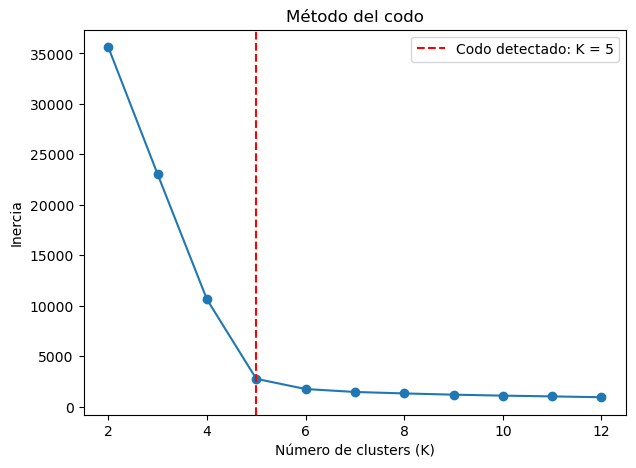

K óptimo según el método del codo: 5


In [40]:
def encontrar_codo(valores_k, valores_y):
    '''Devuelve el valor de K cuya inercia está más alejada de la recta que une
    el primer y el último punto de la curva (K, inercia). Es una forma sencilla y
    objetiva de ubicar el "codo" sin depender solo de la inspección visual.'''
    k_arr = np.array(list(valores_k), dtype=float)
    y_arr = np.array(valores_y, dtype=float)

    p_inicio = np.array([k_arr[0], y_arr[0]])
    p_final = np.array([k_arr[-1], y_arr[-1]])
    direccion = (p_final - p_inicio) / np.linalg.norm(p_final - p_inicio)

    distancias = []
    for kx, vy in zip(k_arr, y_arr):
        vector = np.array([kx, vy]) - p_inicio
        proyeccion = np.dot(vector, direccion) * direccion
        distancia_perpendicular = np.linalg.norm(vector - proyeccion)
        distancias.append(distancia_perpendicular)

    return int(k_arr[np.argmax(distancias)])

k_optimo_codo = encontrar_codo(df_resultados.index, df_resultados["inercia"])

plt.figure(figsize=(7, 5))
plt.plot(df_resultados.index, df_resultados["inercia"], marker="o")
plt.axvline(k_optimo_codo, color="red", linestyle="--",
            label=f"Codo detectado: K = {k_optimo_codo}")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.legend()
plt.show()

print(f"K óptimo según el método del codo: {k_optimo_codo}")

## 6. Método de Silhouette

El coeficiente de Silhouette combina, para cada punto, qué tan cerca está de su propio
cluster (cohesión) frente a qué tan lejos está del cluster más cercano (separación).
Va de -1 a 1: valores altos indican clusters compactos y bien separados. El **K óptimo**
según este criterio es el que **maximiza** el promedio del coeficiente de Silhouette.

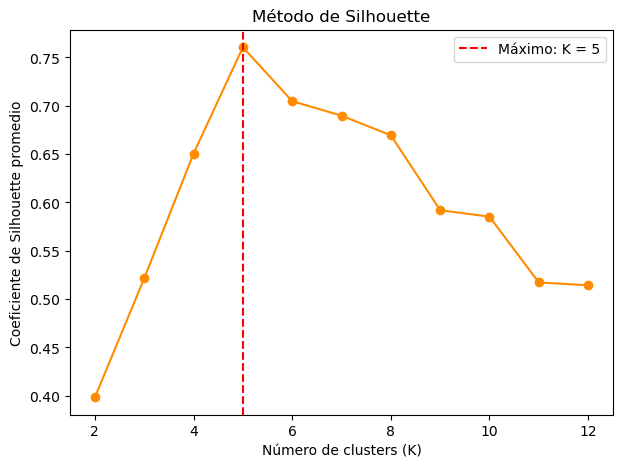

K óptimo según Silhouette: 5
Valor del coeficiente en ese K: 0.7606


In [41]:
k_optimo_silhouette = df_resultados["silhouette"].idxmax()

plt.figure(figsize=(7, 5))
plt.plot(df_resultados.index, df_resultados["silhouette"], marker="o", color="darkorange")
plt.axvline(k_optimo_silhouette, color="red", linestyle="--",
            label=f"Máximo: K = {k_optimo_silhouette}")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Coeficiente de Silhouette promedio")
plt.title("Método de Silhouette")
plt.legend()
plt.show()

print(f"K óptimo según Silhouette: {k_optimo_silhouette}")
print(f"Valor del coeficiente en ese K: {df_resultados.loc[k_optimo_silhouette, 'silhouette']:.4f}")

### Diagrama de Silhouette detallado para el K elegido

Para complementar el promedio, se muestra el diagrama de Silhouette por cluster
(igual al usado en el cuaderno de ejemplo), que permite ver si **todos** los clusters
están bien formados o si alguno en particular tiene puntos mal asignados (barras que
llegan a valores negativos).

In [42]:
k_diag = k_optimo_silhouette
labels_diag = modelos_por_k[k_diag].predict(X_clean)
centros_diag = modelos_por_k[k_diag].cluster_centers_
valores_silhouette = silhouette_samples(X_clean, labels_diag)
silhouette_prom = silhouette_score(X_clean, labels_diag)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.set_xlim([-0.2, 1])
ax1.set_ylim([0, len(X_clean) + (k_diag + 1) * 10])

y_lower = 10
for i in range(k_diag):
    valores_i = valores_silhouette[labels_diag == i]
    valores_i.sort()
    y_upper = y_lower + len(valores_i)
    color = cm.nipy_spectral(float(i) / k_diag)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, valores_i,
                       facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.1, y_lower + 0.5 * len(valores_i), str(i))
    y_lower = y_upper + 10

ax1.axvline(x=silhouette_prom, color="red", linestyle="--")
ax1.set_title(f"Silhouette por cluster (K={k_diag})")
ax1.set_xlabel("Coeficiente de Silhouette")
ax1.set_ylabel("Cluster")
ax1.set_yticks([])

colores_puntos = cm.nipy_spectral(labels_diag.astype(float) / k_diag)
ax2.scatter(X_clean[:, 0], X_clean[:, 1], s=15, c=colores_puntos, alpha=0.7)
ax2.scatter(centros_diag[:, 0], centros_diag[:, 1], marker="o", c="white",
            edgecolor="k", s=200)
for i, c in enumerate(centros_diag):
    ax2.scatter(c[0], c[1], marker=f"${i}$", s=50, edgecolor="k")
ax2.set_title(f"Clusters obtenidos (K={k_diag})")
ax2.set_xlabel("X1")
ax2.set_ylabel("X2")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## 7. Método basado en las etiquetas verdaderas (ground truth)

A diferencia de Silhouette y el codo (que **no** usan información real sobre a qué
grupo pertenece cada punto), aquí sí se aprovecha que, por ser datos sintéticos, se
conoce el grupo real (`y_eval_true`) de cada punto que no es outlier.

Se usan dos métricas estándar para comparar un clustering contra un ground truth:

- **Adjusted Rand Index (ARI)**: mide qué tan de acuerdo están las asignaciones a pares
  de puntos entre el clustering y las clases reales, ajustando por azar. Vale 1 para un
  clustering perfecto y ronda 0 para un agrupamiento aleatorio.
- **Normalized Mutual Information (NMI)**: mide cuánta información comparten las
  etiquetas predichas y las reales (entropía relativa). También vale 1 en el caso ideal.

El **K óptimo** según este método es el que **maximiza el ARI** (se toma como criterio
principal por ser más estricto que NMI y estar ajustado por azar; NMI se reporta como
apoyo).

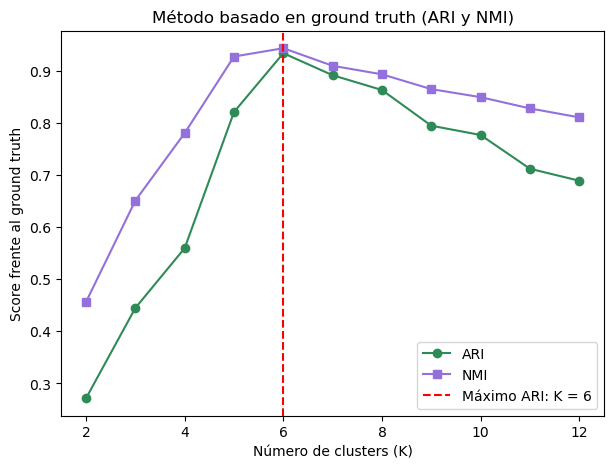

K óptimo según ground truth (ARI): 6
ARI en ese K: 0.9343
NMI en ese K: 0.9439

(Recordatorio: el número real de grupos generados fue 6)


In [ ]:
k_optimo_ground_truth = df_resultados["ARI"].idxmax()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_resultados.index, df_resultados["ARI"], marker="o", label="ARI", color="seagreen")
ax.plot(df_resultados.index, df_resultados["NMI"], marker="s", label="NMI", color="mediumpurple")
ax.axvline(k_optimo_ground_truth, color="red", linestyle="--",
           label=f"Máximo ARI: K = {k_optimo_ground_truth}")
ax.set_xlabel("Número de clusters (K)")
ax.set_ylabel("Score frente al ground truth")
ax.set_title("Método basado en ground truth (ARI y NMI)")
ax.legend()
plt.show()

print(f"K óptimo según ground truth (ARI): {k_optimo_ground_truth}")
print(f"ARI en ese K: {df_resultados.loc[k_optimo_ground_truth, 'ARI']:.4f}")
print(f"NMI en ese K: {df_resultados.loc[k_optimo_ground_truth, 'NMI']:.4f}")
print(f"\n(Recordatorio: el número real de grupos generados fue {n_clusters_real})")

## 8. Comparación de los tres métodos y conclusión

| Método | ¿Usa el ground truth? | K óptimo encontrado |
|---|---|---|
| Método del codo | No | Ver variable `k_optimo_codo` |
| Silhouette | No | Ver variable `k_optimo_silhouette` |
| Ground truth (ARI) | Sí | Ver variable `k_optimo_ground_truth` |

Es muy probable que el **codo** y **Silhouette** coincidan en un valor de K **menor**
a 6 (por ejemplo 5), mientras que el método de **ground truth** sí logre identificar
correctamente los **6 grupos reales**. Esto no es un error: es justamente el efecto
esperado de haber diseñado a propósito dos grupos (4 y 5) parcialmente superpuestos.

Para el codo y para Silhouette, que solo miran la geometría de los puntos (sin conocer
las etiquetas reales), los grupos 4 y 5 lucen casi como una única nube alargada de
puntos, así que "fusionarlos" en un solo cluster produce una solución tan buena o mejor,
según esas métricas, que separarlos en dos. El ground truth, en cambio, sí sabe que en
realidad provienen de dos distribuciones distintas, y por eso premia a K=6.

Esto ilustra una limitación real de K-Means y de los métodos internos de selección de K:
cuando los clusters se superponen, la estructura "verdadera" de los datos puede no ser
la solución que estas métricas favorecen.

In [ ]:
print("Resumen de K óptimos encontrados:")
print(f"  - Método del codo:        K = {k_optimo_codo}")
print(f"  - Silhouette:              K = {k_optimo_silhouette}")
print(f"  - Ground truth (ARI):      K = {k_optimo_ground_truth}")
print(f"  - Número real de grupos:  K = {n_clusters_real}")

Resumen de K óptimos encontrados:
  - Método del codo:        K = 5
  - Silhouette:              K = 5
  - Ground truth (ARI):      K = 6
  - Número real de grupos:  K = 6


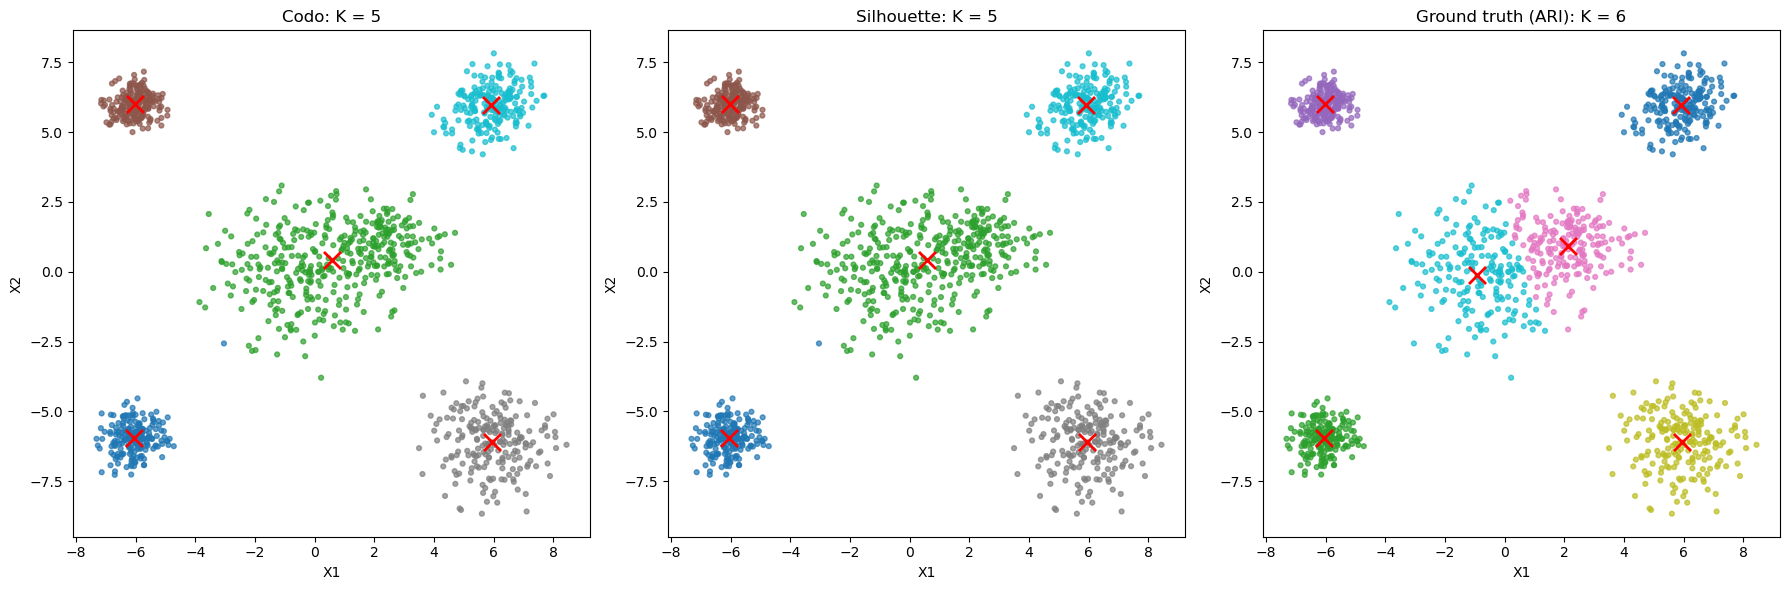

In [ ]:
# Visualización final comparando el resultado de K-Means con cada criterio
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (nombre, k_val) in zip(
    axes,
    [("Codo", k_optimo_codo), ("Silhouette", k_optimo_silhouette),
     ("Ground truth (ARI)", k_optimo_ground_truth)]
):
    modelo = modelos_por_k[k_val]
    labels_pred = modelo.predict(X_clean)
    ax.scatter(X_clean[:, 0], X_clean[:, 1], c=labels_pred, cmap="tab10", s=12, alpha=0.7)
    ax.scatter(modelo.cluster_centers_[:, 0], modelo.cluster_centers_[:, 1],
               c="red", marker="x", s=150, linewidths=2)
    ax.set_title(f"{nombre}: K = {k_val}")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

plt.tight_layout()
plt.show()